Import libraries and data to be used

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tkinter as tk
from tkinter import filedialog

def select_data_file(prompt_title="Select Data File"):
    # Opens a file dialog window to manually choose a file
    root = tk.Tk()
    root.withdraw()
    
    # Bring the file dialog window to the front of the screen
    root.attributes('-topmost', True)
    
    # Open the file picker (restricting it to text and CSV files for convenience)
    file_path = filedialog.askopenfilename(
        title=prompt_title,
        filetypes=[("Text & CSV files", "*.txt *.csv"), ("All files", "*.*")]
    )
    
    # Check if the user pressed cancel
    if not file_path:
        raise FileNotFoundError("❌ Action cancelled. No file was selected.")
        
    print(f"✅ Successfully loaded: {os.path.basename(file_path)}")
    return file_path

#define the raw data paths and read in the unnormalized yaw data for T12
T12_path=select_data_file("Select your T12 IMU DATA file")
T12_yaw_un_norm = pd.read_csv(T12_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for S1
s1_path=select_data_file("Select your S1 IMU DATA file")
s1_yaw_un_norm = pd.read_csv(s1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for the winch
winch_path=select_data_file("Select your Winch IMU DATA file")
winch_yaw_un_norm = pd.read_csv(winch_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized force data
force_path=select_data_file("Select your FORCE DATA file")
force_data_raw = pd.read_csv(force_path,sep=r'\s+', header=None,skiprows=4)

#extract the untrimmed force and event marker data from the raw force data
force_untrimmed = force_data_raw[0].values
em_untrimmed = force_data_raw[1].values


✅ Successfully loaded: T12 IMU Data.csv
✅ Successfully loaded: S1 IMU Data.csv
✅ Successfully loaded: Winch IMU Data.csv
✅ Successfully loaded: Force Data.txt


Time normalise all Yaw data from IMUs to make them the same length using linear interpolation

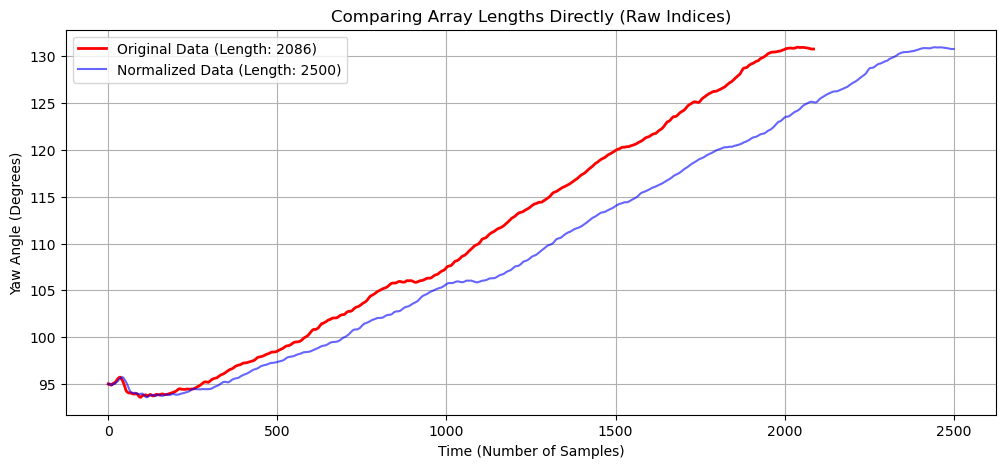

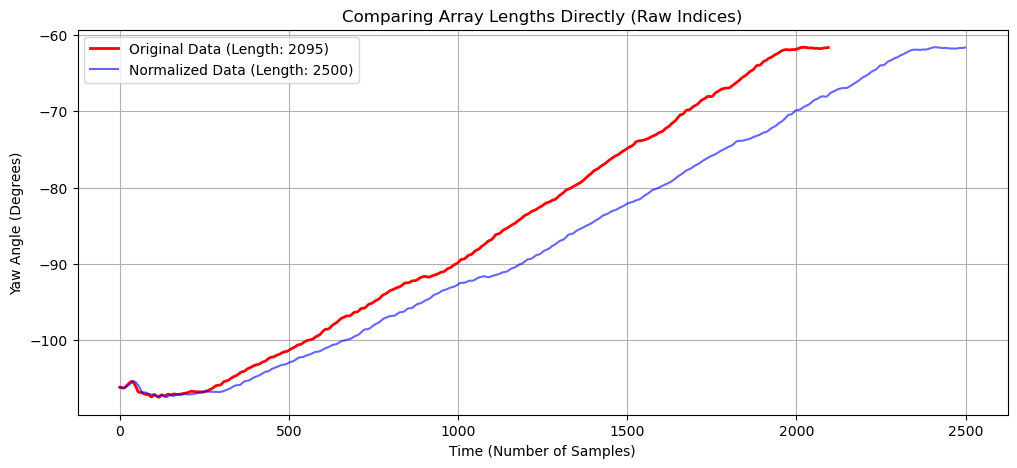

In [2]:
from scipy.interpolate import interp1d

def time_normalize_signal(x, target_length):
    
    #Time-normalizes a signal to a specified target length using interpolation.
    x_flat=x.flatten()
    original_length=len(x_flat)
    old_time = np.arange(0, original_length)
    interpolator = interp1d(old_time, x_flat, kind='linear', bounds_error=True)
    new_time = np.linspace(0, original_length - 1, target_length)
    return interpolator(new_time)

# passess each yaw signal through the time normalization function to get the normalized versions of each signal, all with the same target length of 2500 samples
T12_yaw_norm = time_normalize_signal(T12_yaw_un_norm,2500)
s1_yaw_norm = time_normalize_signal(s1_yaw_un_norm,2500)
winch_yaw_norm = time_normalize_signal(winch_yaw_un_norm,2500)

# Plot the original and normalized data for T12 to compare lengths
plt.figure(figsize=(12, 5))
plt.plot(T12_yaw_un_norm.flatten(), label=f'Original Data (Length: {len(T12_yaw_un_norm)})', color='red', linewidth=2)
plt.plot(T12_yaw_norm, label=f'Normalized Data (Length: {len(T12_yaw_norm)})', color='blue', alpha=0.6)
plt.title('Comparing Array Lengths Directly (Raw Indices)')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Yaw Angle (Degrees)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the original and normalized data for S1 to compare lengths
plt.figure(figsize=(12, 5))
plt.plot(s1_yaw_un_norm.flatten(), label=f'Original Data (Length: {len(s1_yaw_un_norm)})', color='red', linewidth=2)
plt.plot(s1_yaw_norm, label=f'Normalized Data (Length: {len(s1_yaw_norm)})', color='blue', alpha=0.6)
plt.title('Comparing Array Lengths Directly (Raw Indices)')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Yaw Angle (Degrees)')
plt.legend()
plt.grid(True)
plt.show()


Trim the force data to the length denoted by the start and end event markers

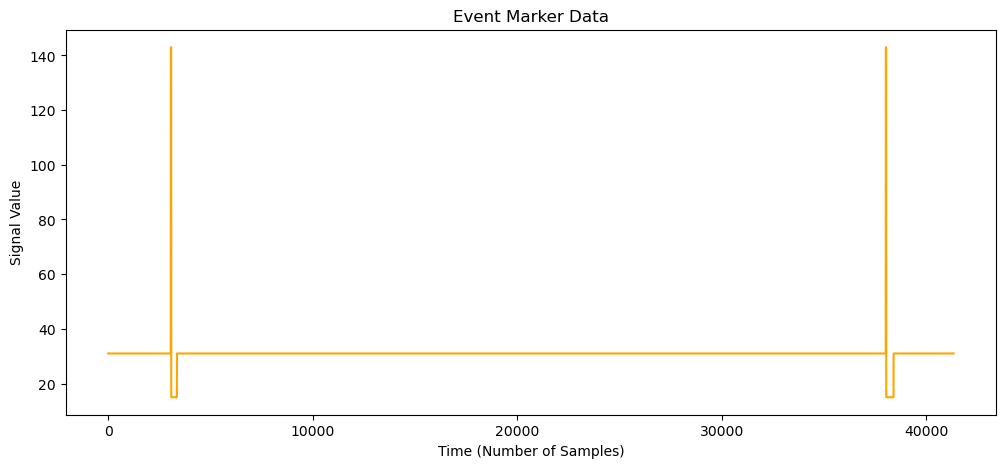

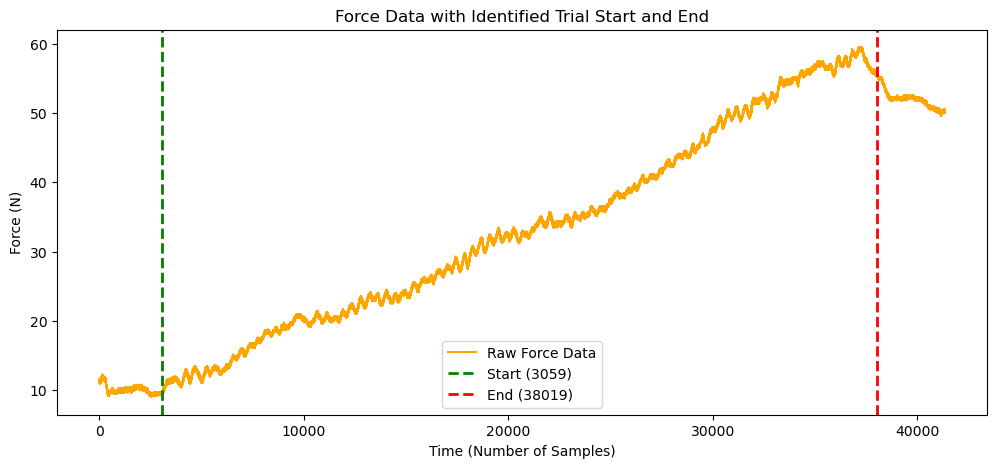

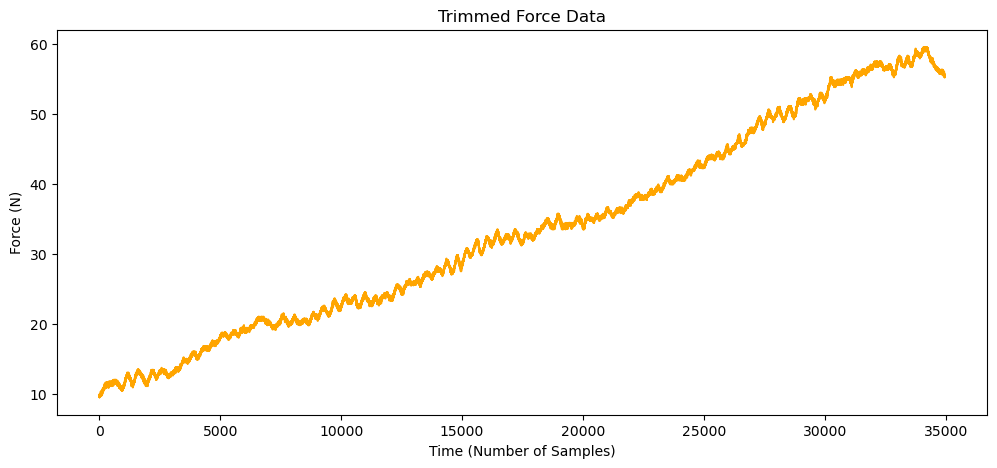

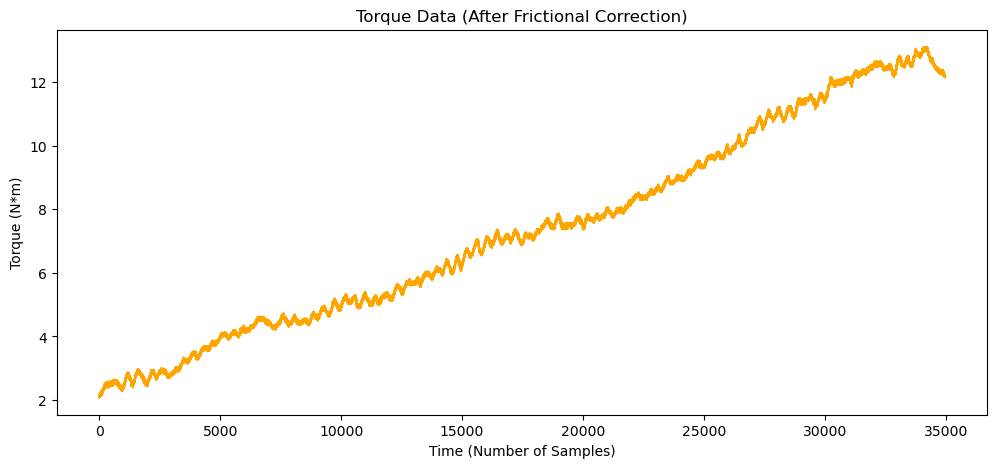

In [3]:
# Create a binary map (True/False or 1/0) of where the signal is above threshold
threshold = 100
above_threshold = (em_untrimmed > threshold).astype(int)

# Calculate the difference to find rising edges (where it goes from 0 to 1)
jumps = np.diff(above_threshold)
rising_edges = np.where(jumps == 1)[0]

# Extract start and end indices
start_index = rising_edges[0]
end_index = rising_edges[1]

# Trim the force data using the identified indices from the event marker data
force_trimmed = force_untrimmed[start_index:end_index]

#Convert the trimmed force data into torque based on radius of the rotating platform 
torque=force_trimmed*0.22

plt.figure(figsize=(12, 5))
plt.plot(em_untrimmed, label='Event Markers (Untrimmed)', color='orange')
plt.title('Event Marker Data')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Signal Value')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(force_untrimmed, label='Raw Force Data', color='orange')
plt.axvline(x=start_index, color='green', linestyle='--', linewidth=2, label=f'Start ({start_index})')
plt.axvline(x=end_index, color='red', linestyle='--', linewidth=2, label=f'End ({end_index})')
plt.title('Force Data with Identified Trial Start and End')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Force (N)')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(force_trimmed, label='Force Data (Trimmed)', color='orange')
plt.title('Trimmed Force Data')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Force (N)')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(torque, label='Torque', color='orange')
plt.title('Torque Data (After Frictional Correction)')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Torque (N*m)')
plt.show()


Fit a polynomial to smooth the torque data and then check for spikes that may be related to tensing

✅ Good Positive Fit (Poly3)
✅ Good Negative Fit (Poly3)


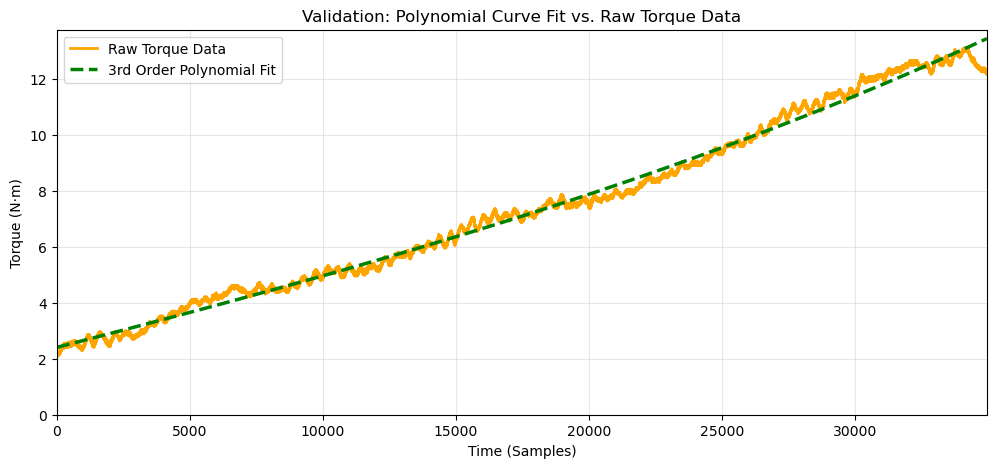

In [4]:
#Establishes the time index (1 to length of torque)
time = np.arange(1, len(torque) + 1)

#Fit a 3rd order polynomial and evaluate it
coefficients = np.polyfit(time, torque, 3)
torque_fit = np.polyval(coefficients, time)

#Calculates residuals (difference between real data and fitted line)
resid_torque = torque - torque_fit

#Checks against the threshold for tensing (threshold established in a separate data collection)
threshold = 3.0
max_residual = np.max(resid_torque)
min_residual = np.min(resid_torque)

#Check positive residuals
if max_residual > threshold:
    print("⚠️ Warning: High Positive Residuals (Poly3)")
else:
    print("✅ Good Positive Fit (Poly3)")

#Checks negative residuals
if min_residual < -threshold:
    print("⚠️ Warning: High Negative Residuals (Poly3)")
else:
    print("✅ Good Negative Fit (Poly3)")

plt.figure(figsize=(12, 5))
plt.plot(time, torque, label='Raw Torque Data', color='orange', linewidth=2)
plt.plot(time, torque_fit, label='3rd Order Polynomial Fit', color='green', linestyle='--', linewidth=2.5)
plt.title('Validation: Polynomial Curve Fit vs. Raw Torque Data')
plt.xlabel('Time (Samples)')
plt.ylabel('Torque (N·m)')
plt.xlim(0, len(torque))
plt.ylim(0, max(torque) * 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Use the winch IMU data to establish the start and end of the trial. Then use these start and end indices to trim the T12 and S1 Yaw data. 

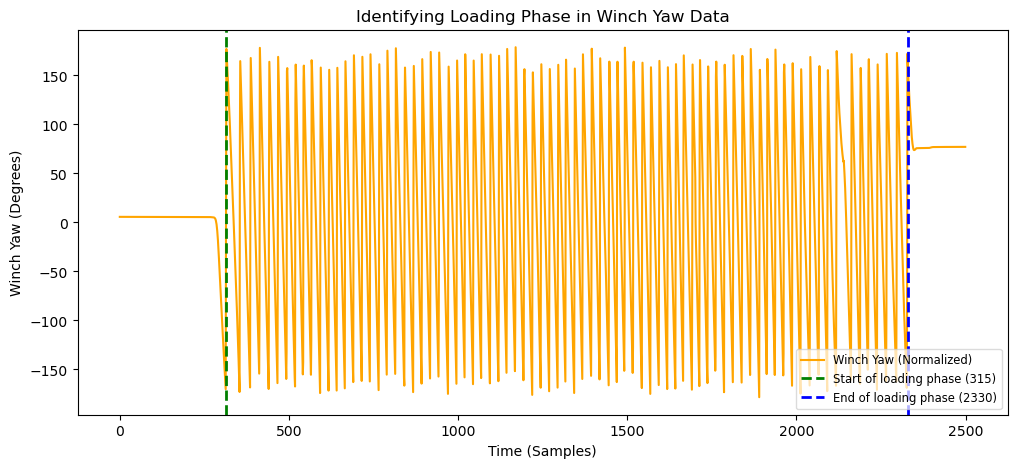

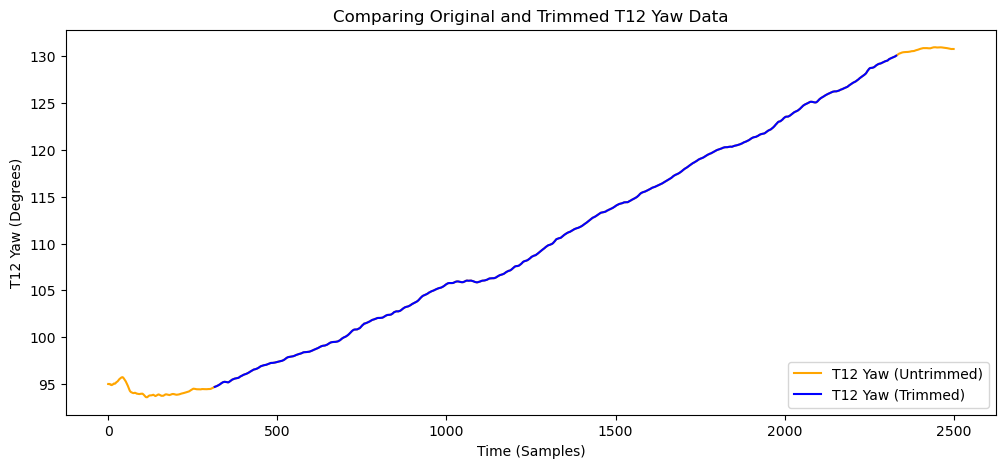

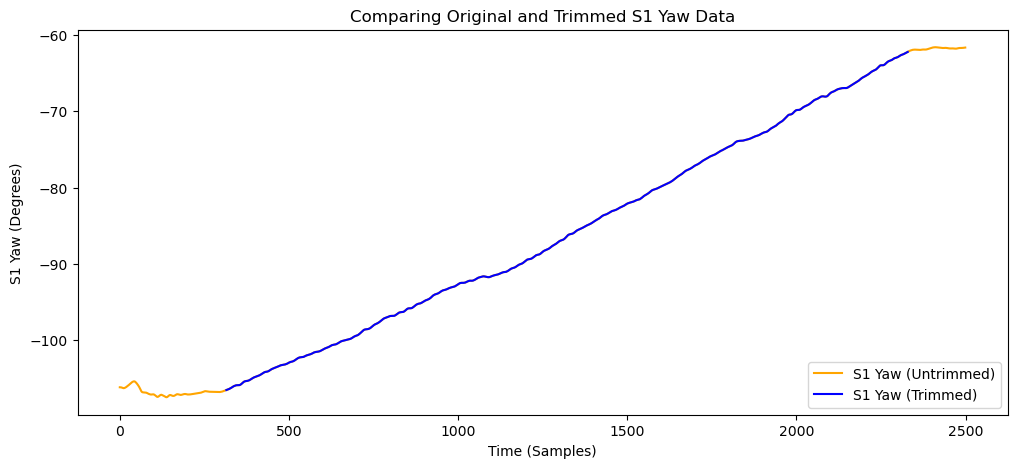

In [5]:
#sets threshold for peaks and then finds all instances above this threshold.
threshold = 150
active_frames = np.where(winch_yaw_norm > threshold)[0]

#finds the start and end indices of the loading phase based on the identified active frames
start_index_winch = active_frames[0]
end_index_winch = active_frames[-1]

#trims the T12 and S1 yaw data using the identified start and end indices from the winch yaw data
T12_yaw_trim = T12_yaw_norm[start_index_winch:end_index_winch]
s1_yaw_trim = s1_yaw_norm[start_index_winch:end_index_winch]

#Create timelines for the original and trimmed data to ensure they align correctly on the x-axis
original_timeline = np.arange(len(T12_yaw_norm))
trimmed_timeline = np.arange(start_index_winch, end_index_winch)

#Plot the winch yaw data with vertical lines indicating the start and end of the data collection
plt.figure(figsize=(12, 5))
plt.plot(winch_yaw_norm, label='Winch Yaw (Normalized)', color='orange')
plt.axvline(x=start_index_winch, color='green', linestyle='--', linewidth=2, label=f'Start of loading phase ({start_index_winch})')
plt.axvline(x=end_index_winch, color='blue', linestyle='--', linewidth=2, label=f'End of loading phase ({end_index_winch})')
plt.title('Identifying Loading Phase in Winch Yaw Data')
plt.xlabel('Time (Samples)')
plt.ylabel('Winch Yaw (Degrees)')
plt.legend(loc='lower right',fontsize='small', framealpha=0.7)
plt.show()

#Plot the original and trimmed T12 and S1 yaw data to visually confirm the trimming process
plt.figure(figsize=(12, 5))
plt.plot(original_timeline, T12_yaw_norm, label='T12 Yaw (Untrimmed)', color='orange')
plt.plot(trimmed_timeline, T12_yaw_trim, label='T12 Yaw (Trimmed)', color='blue' )
plt.title('Comparing Original and Trimmed T12 Yaw Data')
plt.xlabel('Time (Samples)')
plt.ylabel('T12 Yaw (Degrees)')
plt.legend(loc='lower right')
plt.show()  

#Plot the original and trimmed S1 yaw data to visually confirm the trimming process
plt.figure(figsize=(12, 5))
plt.plot(original_timeline, s1_yaw_norm, label='S1 Yaw (Untrimmed)', color='orange')
plt.plot(trimmed_timeline, s1_yaw_trim, label='S1 Yaw (Trimmed)', color='blue' )
plt.title('Comparing Original and Trimmed S1 Yaw Data')
plt.xlabel('Time (Samples)')
plt.ylabel('S1 Yaw (Degrees)')
plt.legend(loc='lower right')
plt.show()  


Calculate the range of movement of the lumbar spine from the T12 and S1 Yaws

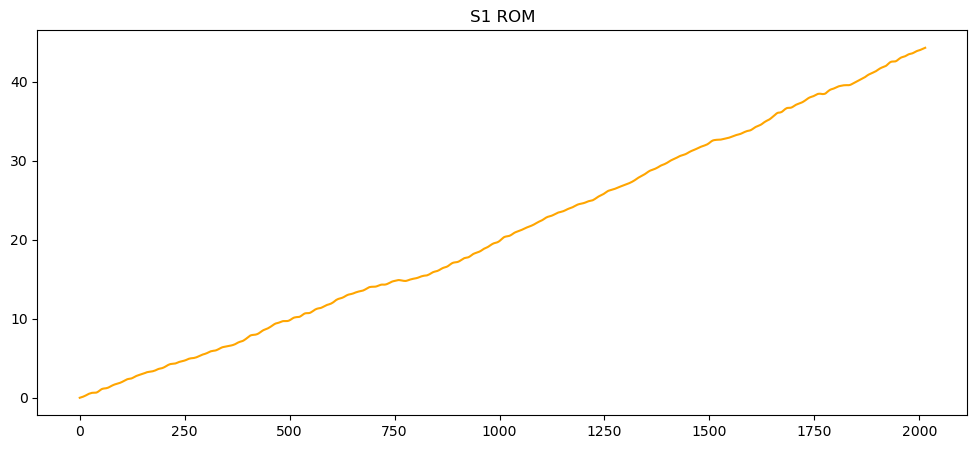

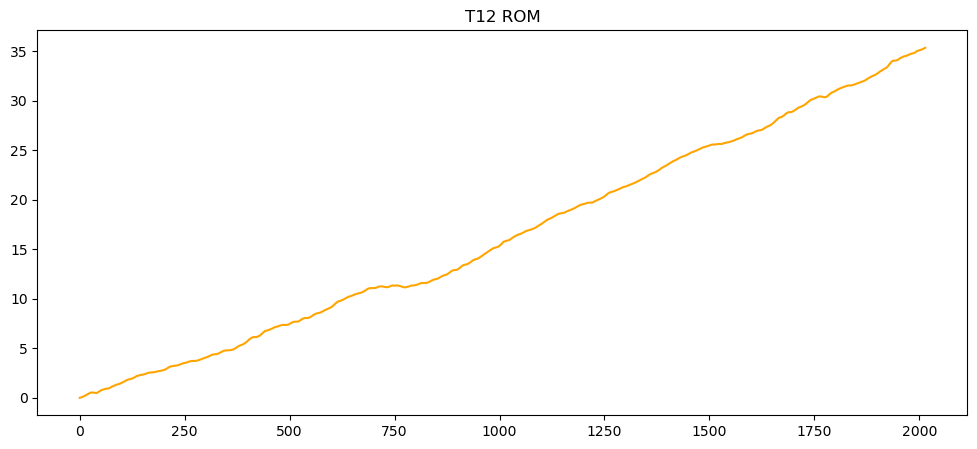

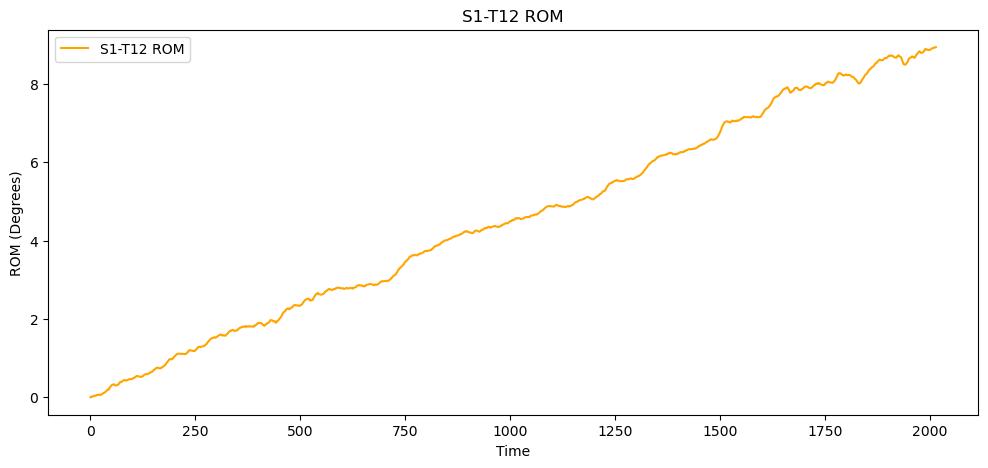

In [10]:

s1_start_yaw = s1_yaw_trim[0]
s1_ROM = s1_yaw_trim - s1_start_yaw

plt.figure(figsize=(12, 5))     
plt.plot(s1_ROM, label='S1 ROM', color='orange')
plt.title('S1 ROM')  

T12_start_yaw = T12_yaw_trim[0]
T12_ROM = T12_yaw_trim - T12_start_yaw

plt.figure(figsize=(12, 5)) 
plt.plot(T12_ROM, label='T12 ROM', color='orange')
plt.title('T12 ROM')

ROM = s1_ROM - T12_ROM

plt.figure(figsize=(12, 5)) 
plt.plot(ROM, label='S1-T12 ROM', color='orange')
plt.title('S1-T12 ROM')
plt.xlabel('Time')
plt.ylabel('ROM (Degrees)')
plt.legend()

Fit a polynomial to smooth out the ROM data to eliminate sensor noise

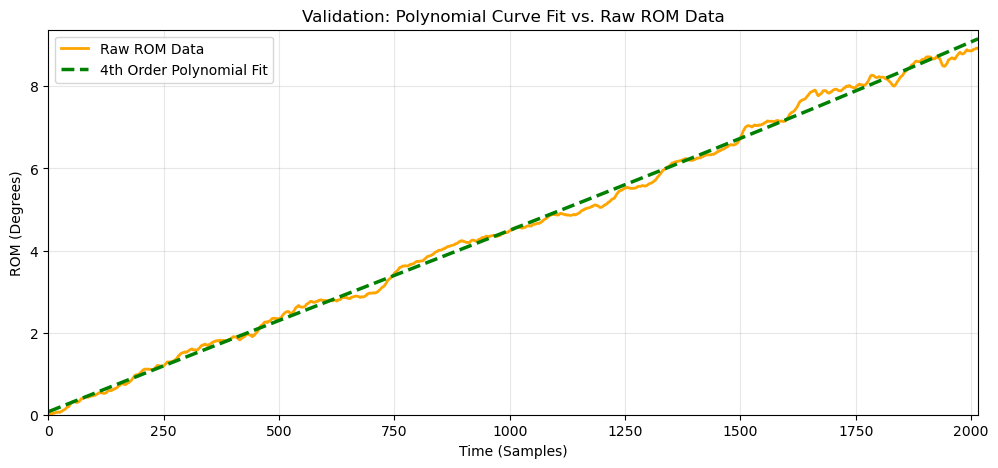

0.0752867062303156


In [11]:
#Establishes the time index (1 to length of torque)
time = np.arange(1, len(ROM) + 1)

#Fit a 2nd order polynomial and evaluate it
coefficients = np.polyfit(time, ROM, 3)
ROM_fit = np.polyval(coefficients, time)

plt.figure(figsize=(12, 5))
plt.plot(time, ROM, label='Raw ROM Data', color='orange', linewidth=2)
plt.plot(time, ROM_fit, label='4th Order Polynomial Fit', color='green', linestyle='--', linewidth=2.5)
plt.title('Validation: Polynomial Curve Fit vs. Raw ROM Data')
plt.xlabel('Time (Samples)')
plt.ylabel('ROM (Degrees)')
plt.xlim(0, len(ROM))
plt.ylim(0, max(ROM) * 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(ROM_fit[0])

Time normalise the ROM and torque data

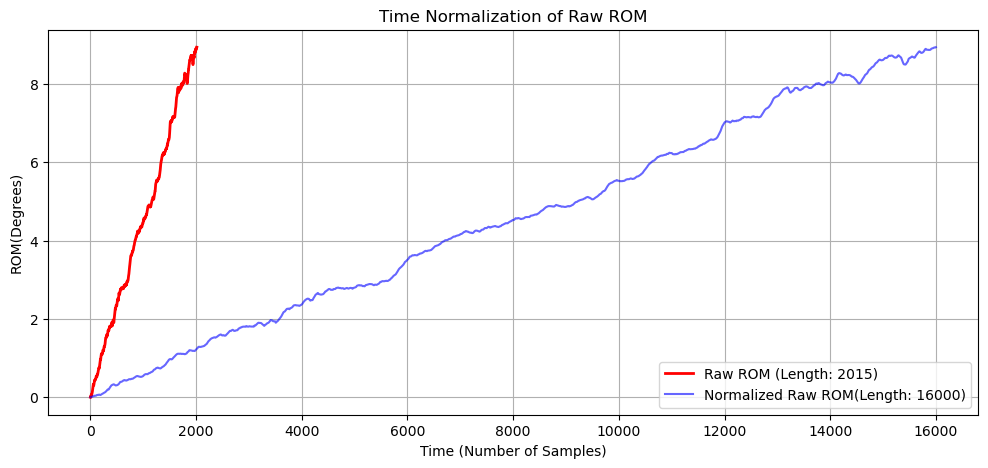

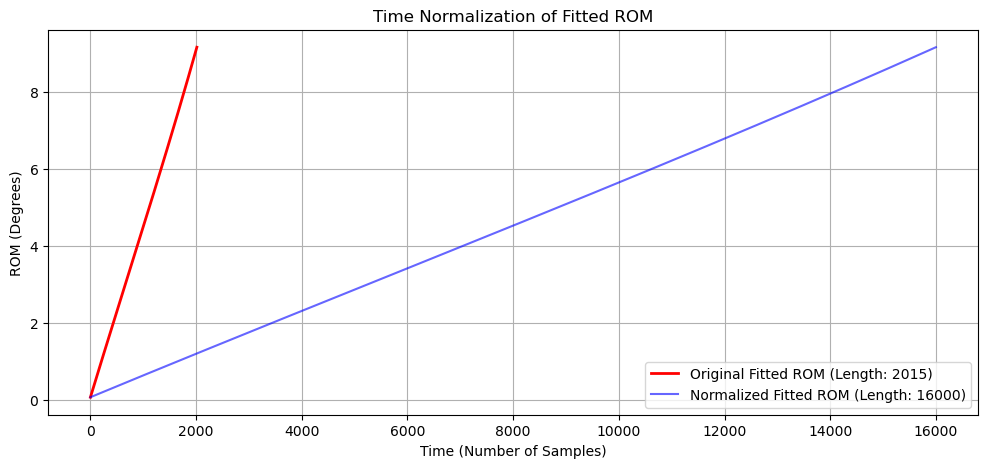

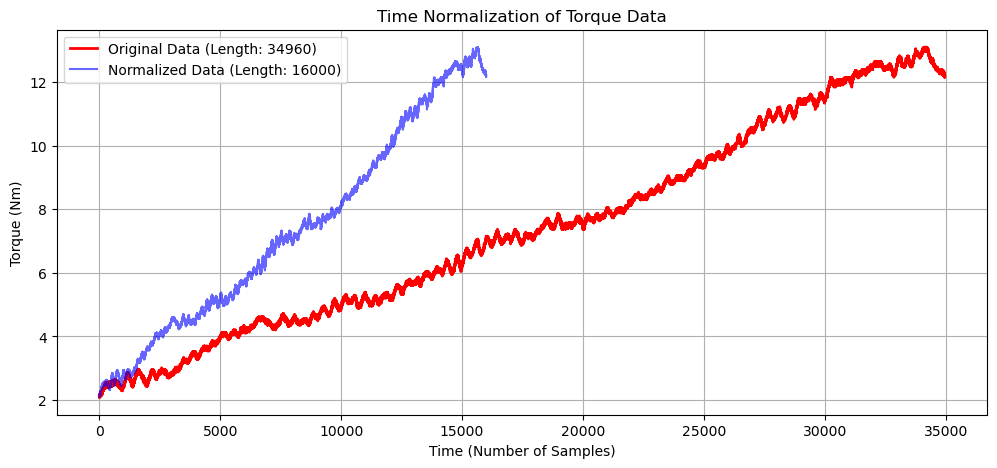

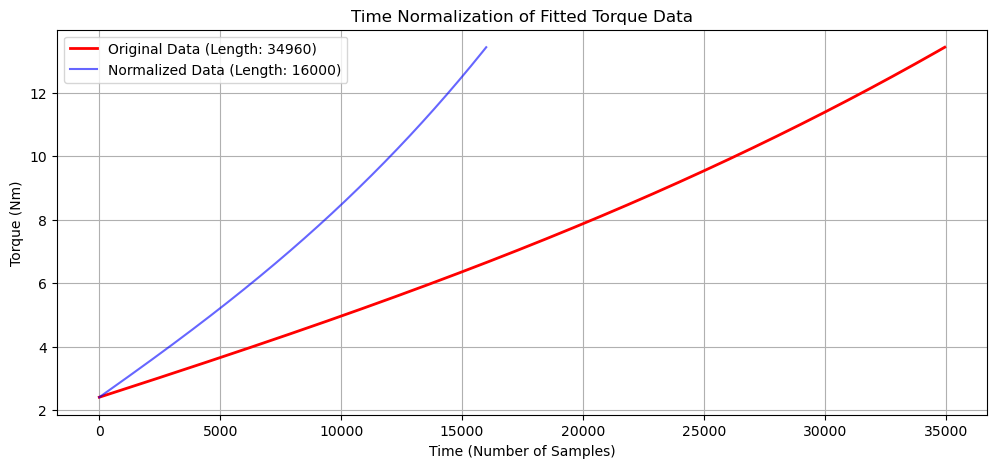

In [12]:
ROM_norm = time_normalize_signal(ROM,16000)
ROM_fit_norm = time_normalize_signal(ROM_fit,16000)

plt.figure(figsize=(12, 5))
plt.plot(ROM, label=f'Raw ROM (Length: {len(ROM)})', color='red', linewidth=2)
plt.plot(ROM_norm, label=f'Normalized Raw ROM(Length: {len(ROM_norm)})', color='blue', alpha=0.6)
plt.title('Time Normalization of Raw ROM')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('ROM(Degrees)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(ROM_fit, label=f'Original Fitted ROM (Length: {len(ROM_fit)})', color='red', linewidth=2)
plt.plot(ROM_fit_norm, label=f'Normalized Fitted ROM (Length: {len(ROM_fit_norm)})', color='blue', alpha=0.6)
plt.title('Time Normalization of Fitted ROM')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('ROM (Degrees)')
plt.legend()
plt.grid(True)
plt.show()

torque_norm = time_normalize_signal(torque,16000)
torque_fit_norm = time_normalize_signal(torque_fit,16000)

plt.figure(figsize=(12, 5))
plt.plot(torque.flatten(), label=f'Original Data (Length: {len(torque)})', color='red', linewidth=2)
plt.plot(torque_norm, label=f'Normalized Data (Length: {len(torque_norm)})', color='blue', alpha=0.6)
plt.title('Time Normalization of Torque Data')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(torque_fit.flatten(), label=f'Original Data (Length: {len(torque_fit)})', color='red', linewidth=2)
plt.plot(torque_fit_norm, label=f'Normalized Data (Length: {len(torque_fit_norm)})', color='blue', alpha=0.6)
plt.title('Time Normalization of Fitted Torque Data')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid(True)
plt.show()

Combine ROM and Torque on one graph

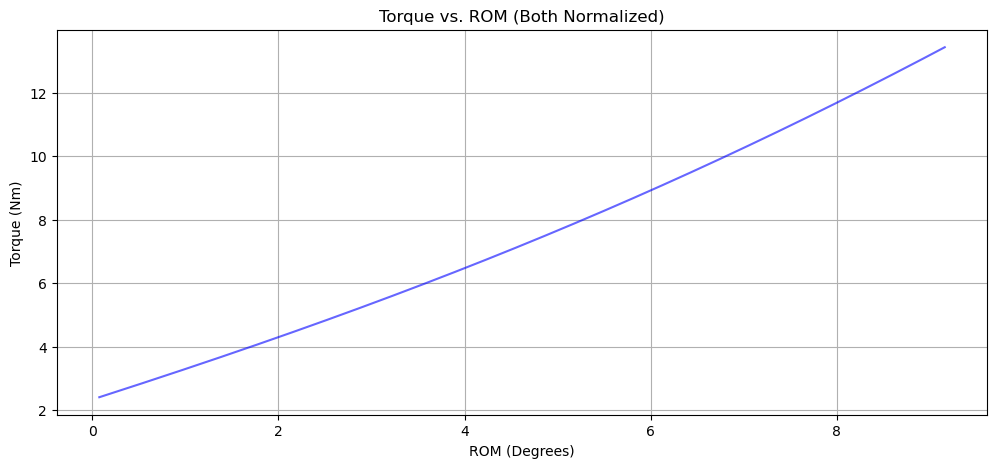

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(ROM_fit_norm, torque_fit_norm, label=f'', color='blue', alpha=0.6)
plt.title('Torque vs. ROM (Both Normalized)')
plt.xlabel('ROM (Degrees)')
plt.ylabel('Torque (Nm)')
plt.grid(True)
plt.show()